# 🎮 E-Sports Biometrics & Gamer Performance: Exploratory Data Analysis

Welcome to this Exploratory Data Analysis (EDA) notebook! 

In this notebook, we will dive into the **250,000-row synthetic dataset** of gamer biometrics. Our goal is to understand how physiological factors (like sleep, heart rate, and fatigue) and environmental factors (like caffeine and screen brightness) impact a player's in-game performance (reaction time and match outcome).

### Notebook Structure:
1. **Setup and Data Loading:** Setup and Inspecting the raw data.
2. **Data Cleaning:** Handling the intentional missing values.
3. **Univariate Analysis:** Looking at individual feature distributions.
4. **Bivariate Analysis:** Exploring the relationships between biometrics and performance.
5. **Conclusion:** Summarizing the key findings.

# 1. Setup and Data Loading

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sarveshchhetri/e-sports-biometrics-and-performance/esports_gaming_biometrics_250k.csv
/kaggle/input/datasets/sarveshchhetri/e-sports-biometrics-and-performance/data_dictionary.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles
sns.set_theme(style="darkgrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# load the dataset
df = pd.read_csv('/dataset/esports_gaming_biometrics_250k.csv')

# first 5 row
display(df.head())

# check dataset structure and data types
df.info()

,Player_ID,Age,Game_Genre,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,Blue_Light_Filter,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms,Match_Outcome
0,PL_000001,24,FPS,1.41,8.88,0,43.4,Yes,107,78,95.02,268.96,Loss
1,PL_000002,22,FPS,4.43,7.45,2,88.0,Yes,110,102,82.92,281.90,Win
2,PL_000003,25,Battle Royale,3.75,8.10,1,24.8,Yes,152,96,89.13,288.57,Win
3,PL_000004,29,FPS,1.76,6.69,0,80.2,No,151,65,80.41,279.76,Win
4,PL_000005,22,FPS,5.79,8.17,1,34.4,No,148,95,95.71,229.62,Loss


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Player_ID          250000 non-null  object 
 1   Age                250000 non-null  int64  
 2   Game_Genre         250000 non-null  object 
 3   PlayTime_Hours     250000 non-null  float64
 4   Sleep_Hours        250000 non-null  float64
 5   Energy_Drinks      250000 non-null  int64  
 6   Screen_Brightness  237452 non-null  float64
 7   Blue_Light_Filter  250000 non-null  object 
 8   APM                250000 non-null  int64  
 9   Heart_Rate_BPM     250000 non-null  int64  
 10  HRV_Score          245066 non-null  float64
 11  Reaction_Time_ms   250000 non-null  float64
 12  Match_Outcome      250000 non-null  object 
dtypes: float64(5), int64(4), object(4)
memory usage: 24.8+ MB


# 2. Data cleaning
Let's check for missing values. This dataset contains simulated sensor failures in `Screen_Brightness` and `HRV_Score`.

In [4]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Player_ID                0
Age                      0
Game_Genre               0
PlayTime_Hours           0
Sleep_Hours              0
Energy_Drinks            0
Screen_Brightness    12548
Blue_Light_Filter        0
APM                      0
Heart_Rate_BPM           0
HRV_Score             4934
Reaction_Time_ms         0
Match_Outcome            0
dtype: int64


In [5]:
# impute missing values with the median for simplicity
df['Screen_Brightness'] = df['Screen_Brightness'].fillna(df['Screen_Brightness'].median())
df['HRV_Score'] = df['HRV_Score'].fillna(df['HRV_Score'].median())

print("\nMissing values after cleaning:\n",df.isnull().sum())


Missing values after cleaning:
 Player_ID            0
Age                  0
Game_Genre           0
PlayTime_Hours       0
Sleep_Hours          0
Energy_Drinks        0
Screen_Brightness    0
Blue_Light_Filter    0
APM                  0
Heart_Rate_BPM       0
HRV_Score            0
Reaction_Time_ms     0
Match_Outcome        0
dtype: int64


# 3. Univariate analysis
Let's understand the distributions of our gamers.

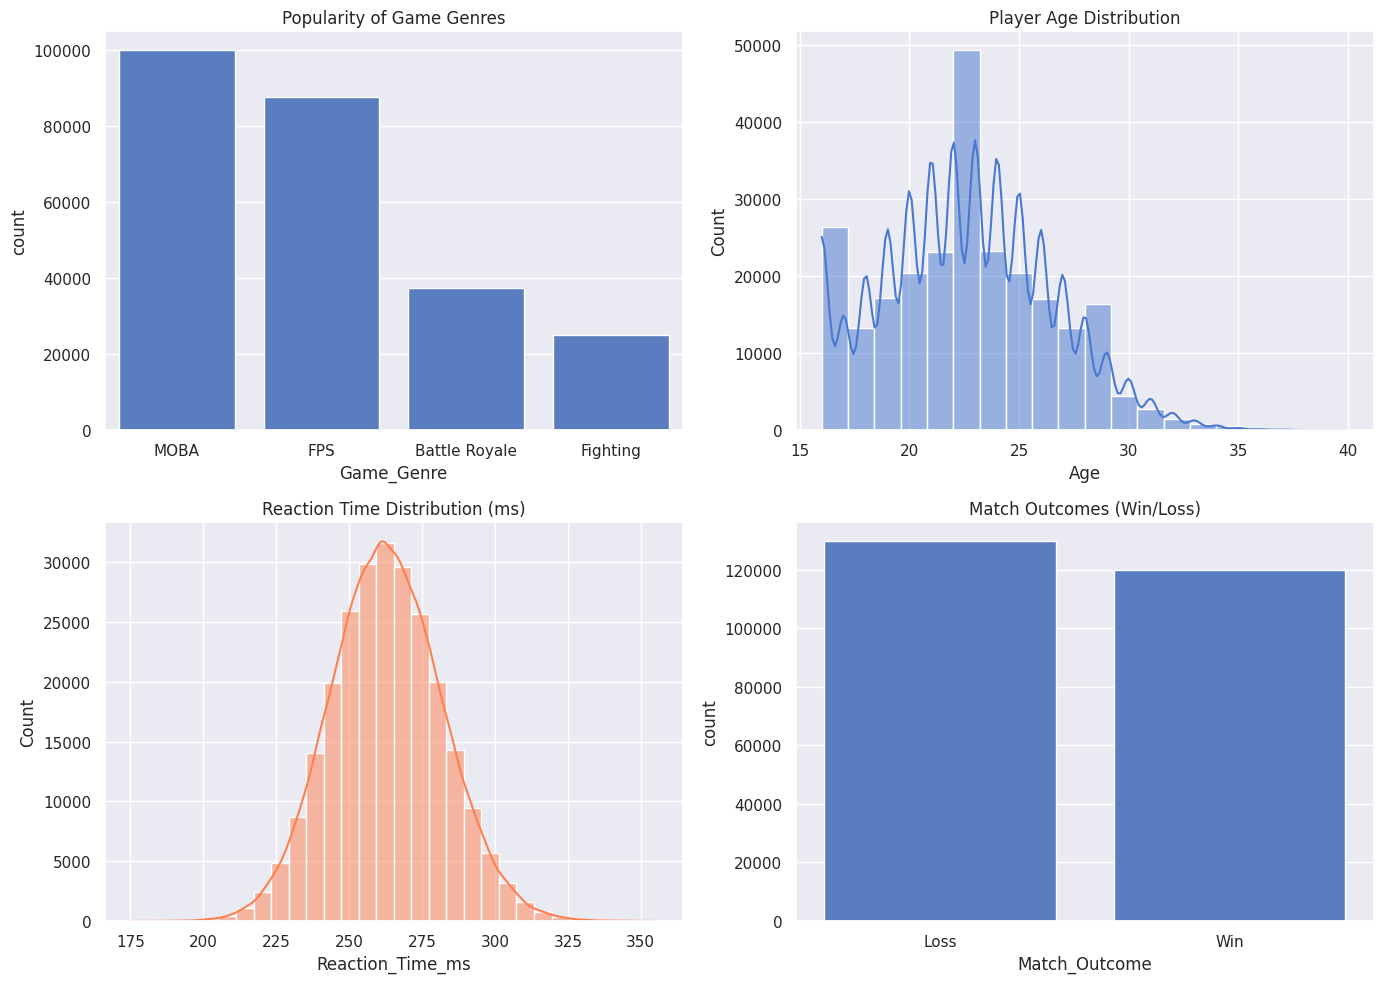

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# game genre Distribution
sns.countplot(data=df, x='Game_Genre', ax=axes[0,0], order=df['Game_Genre'].value_counts().index)
axes[0,0].set_title('Popularity of Game Genres')

# age distribution
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title('Player Age Distribution')

# reaction time distribution
sns.histplot(df['Reaction_Time_ms'], bins=30, kde=True, ax=axes[1,0], color='coral')
axes[1,0].set_title('Reaction Time Distribution (ms)')

# match outcome
sns.countplot(data=df, x='Match_Outcome', ax=axes[1,1])
axes[1,1].set_title('Match Outcomes (Win/Loss)')
plt.tight_layout()

# 4. Bivariate analysis 
How do biological factors affect gaming performance?

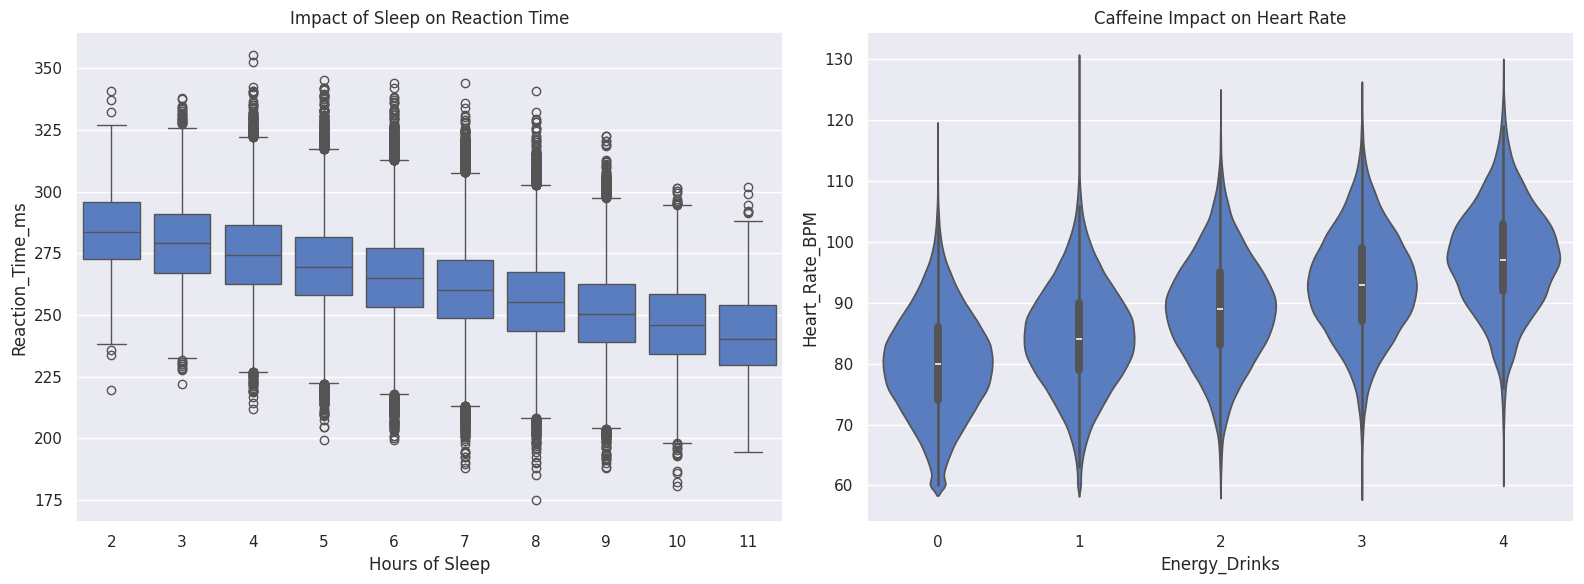

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sleep vs Reaction Time
# using a boxplot for clearer visualization over large data
df['Sleep_Rounded']= df['Sleep_Hours'].round().astype(int)
sns.boxplot(data=df, x='Sleep_Rounded',y='Reaction_Time_ms', ax=axes[0])
axes[0].set_title('Impact of Sleep on Reaction Time')
axes[0].set_xlabel('Hours of Sleep')

# Energy Drinks vs Heart Rate
sns.violinplot(data=df, x='Energy_Drinks', y='Heart_Rate_BPM', ax=axes[1])
axes[1].set_title('Caffeine Impact on Heart Rate')

plt.tight_layout()
df.drop('Sleep_Rounded', axis=1, inplace=True) 

### What about Match Outcomes?
Let's see if winners have fundamentally different reaction times and APM.

Text(0.5, 1.0, 'Actions Per Minute (APM) by Match Outcome')

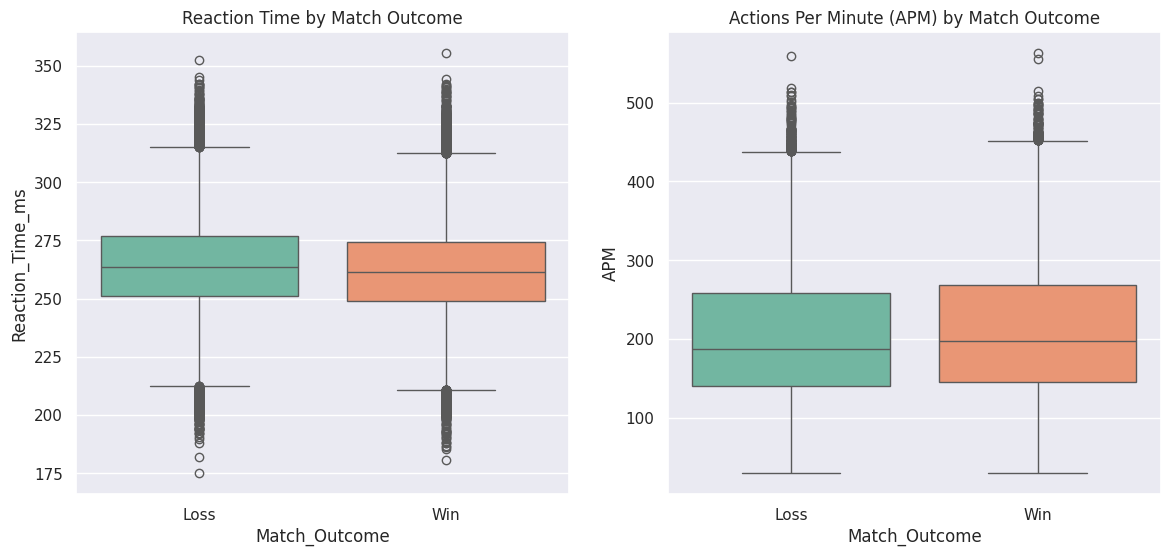

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Match_Outcome', y='Reaction_Time_ms', ax=axes[0], palette='Set2')
axes[0].set_title('Reaction Time by Match Outcome')

sns.boxplot(data=df, x='Match_Outcome', y='APM', ax=axes[1], palette='Set2')
axes[1].set_title('Actions Per Minute (APM) by Match Outcome')

# 5. Feature Correlation Heatmap 
To wrap up our EDA, let's look at the linear correlations across all numerical features.

Text(0.5, 1.0, 'Biometrics & Performance Correlation Matrix')

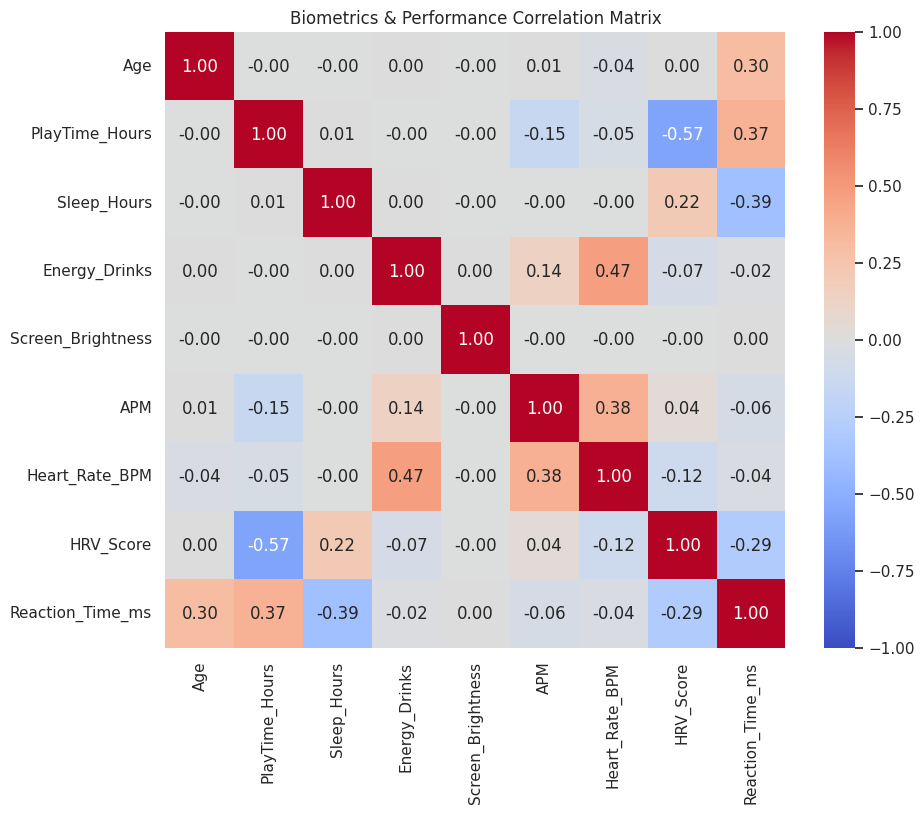

In [9]:
plt.figure(figsize=(10, 8))

# select only numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Biometrics & Performance Correlation Matrix')

## Conclusion & Takeaways 

Based on this quick exploration, we found several key patterns:
1. **Sleep is crucial:** Players with higher hours of sleep tend to have lower (faster) reaction times.
2. **Caffeine is a double-edged sword:** Energy drinks increase the player's heart rate, but excessive consumption might negatively impact performance (jitters).
3. **Speed Wins:** Winners generally exhibit slightly faster reaction times and significantly higher APM compared to losers.
4. **Data Readiness:** The dataset is now clean and ready for machine learning. 

*Next Steps:* You can use this cleaned data to build an XGBoost or Random Forest model to predict `Match_Outcome` or `Reaction_Time_ms`!

---
**If you found this notebook helpful, please consider upvoting the dataset and this notebook!**